### Beginning ConvNeXt

This post is about learning more about ConvNeXt:   
https://arxiv.org/pdf/2201.03545   

Note there is also a second version to the ConvNeXt:
https://arxiv.org/pdf/2301.00808   


However, in this post I focus more on original ConvNeXt

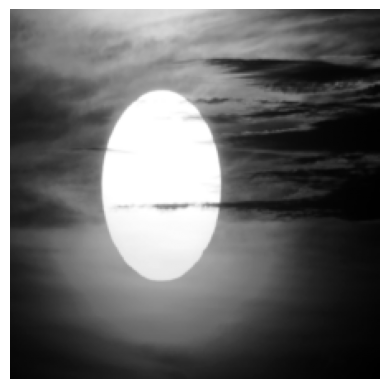

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO

'''
Let's download an image from the internet to make this as real as possible

Four dimensions for Conv2D
Because we are using torch, the shape is (Batch, in_channels, Height, Width)
Because in_channels is 1, we are dealing with a gray scale image
'''

dims = 224
in_channels = 1
out_channels = 4
input_shape = (1, in_channels, dims, dims)
kernel_size = 4

# Let us get an image to work with
# define a url of an image we would like to download
url = "https://static.vecteezy.com/system/resources/thumbnails/012/203/322/original/beautiful-fiery-sunset-in-the-sky-the-sun-sets-over-the-horizon-view-of-the-sun-circle-at-sunset-video.jpg"
response = requests.get(url)
response.raise_for_status()

# Open up the downloaded image
image = Image.open(fp=BytesIO(initial_bytes=response.content))

# With the image in place, prepare to adjust the size for 224,224
transform = transforms.Compose(
    transforms=[
        transforms.Grayscale(num_output_channels=in_channels),  # Currently 3 channels change to 1
        transforms.Resize(size=(224,224)), # Convert to grayscale
        transforms.ToTensor()   # Make the results a pytorch tensor (C, H, W)
    ]
)

# Apply the transform to the image
x = transform(image)

# Plot the image, so can see what our input looks like
plt.imshow(x.squeeze(), cmap='gray')
plt.axis('off');

In [2]:
# With our input in place, let's build up our model
# First setup the class for the stem to do the patchfying
class PatchifyStem(nn.Module):
    def __init__(self, in_channels=in_channels, out_channels=in_channels, kernel_size=kernel_size):
        super().__init__()

        # This is the Convoluationl layer which does the patchfying
        self.proj = nn.Conv2d(
            in_channels=in_channels, 
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=kernel_size,
        )

    def forward(self, x):
        return self.proj(x)
    
# Call the class
stem = PatchifyStem(in_channels=in_channels, out_channels=in_channels)
stem_out = stem(x.unsqueeze(dim=0))
stem_out.shape

torch.Size([1, 1, 56, 56])

In [3]:
'''
The stem so far, is so far identical to what is done in the ViT architecture.
In the original Convolutional architecture, we may have the input -> Conv -> Max Pool
Now we replace that process with patchifying.

'''

# Let's build the block 
class DummyBlock(nn.Module):

    def __init__(self, ):
        super().__init__()
    # Setup the stages


    def forward(self, x):
        return x
    
DummyBlock()(stem_out).shape

torch.Size([1, 1, 56, 56])

In [4]:
# Setup a dummy stage
# This is just to get the core idea of how the stages are built
class Stage(nn.Module):
    def __init__(self, depth):
        super().__init__()

        self.blocks = nn.Sequential(
            *[ DummyBlock() for _ in range(depth)]
        )

    
    def forward(self, x):
        return x
    

# Test the stage
Stage1 = Stage(depth=3)
print(Stage1)
   
stage1_out = Stage1(stem_out)
stage1_out.shape

Stage(
  (blocks): Sequential(
    (0): DummyBlock()
    (1): DummyBlock()
    (2): DummyBlock()
  )
)


torch.Size([1, 1, 56, 56])

In [5]:
'''
Let build on this and build one block on its own
Out first convolution is not a normal but a depthwise convolution
To get this depthwise covolution, we will leverage the **groups** argument nn.Conv2d

Given we have our shape above as (1, 1, 56, 56) -> (Batch, channels, height, width) 
let's use a temporary shape to make things a bit cleaner.

A normal convolution mixes information between channels, basically every output channel looks at every input channel

In a depthwise convolution, the information is processed independently. 
No mixing of information is done at this stage.
Later a 1x1 convolution is used to mix information between the channels

It is also computationally cheaper as the number of parameters are rduced.

Here are two examples

'''

# Define a leyer
conv_no_groups = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=4, stride=4, bias=True)
print('Num of parameters for conv with no groups: ', sum([ p.numel() for p in conv_no_groups.parameters() ]))


conv_with_groups = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=4, stride=4, groups=3, bias=True)
print('Num of parameters for conv with groups: ', sum([ p.numel() for p in conv_with_groups.parameters() ]))

# As we can see grouped convolution uses less parameters

Num of parameters for conv with no groups:  294
Num of parameters for conv with groups:  102


In [6]:
# Set the seed to ensure deterministic results
torch.manual_seed(1)

# With that understanding, let's build our class to implement depthwise convolution
class DepthWiseConv(nn.Module):
    def __init__(self, in_channels, out_channels, groups=1):
        super().__init__()

        self.dwconv = nn.Conv2d(
            in_channels=in_channels, 
            out_channels=out_channels, 
            kernel_size=7, 
            padding=3, 
            stride=1,
            groups=groups
            )

    
    def forward(self, x):
        return self.dwconv(x)
    

# Test the function
dw_conv = DepthWiseConv(in_channels=in_channels, out_channels=in_channels)
dw_conv_out = dw_conv(stem_out)
print('Depth Conv Output: ', dw_conv_out.shape)
print('Stem Output: ', stem_out.shape)

Depth Conv Output:  torch.Size([1, 1, 56, 56])
Stem Output:  torch.Size([1, 1, 56, 56])


In [7]:
'''
Notice that the output size of both the stem_out and the output from the groupsize convolutional operation are the same.
After the groupwise operation the size did not change because we used the padding of 3 and a stride of 1.

We could also confirm that also if we use the following operations
(((shape_of_input - kernel_size) + (2 * padding) ) / stride ) + 1

(((56-7) + (2*3)) / 1) + 1 -> 56

This matches the output above.
'''

'\nNotice that the output size of both the stem_out and the output from the groupsize convolutional operation are the same.\nAfter the groupwise operation the size did not change because we used the padding of 3 and a stride of 1.\n\nWe could also confirm that also if we use the following operations\n(((shape_of_input - kernel_size) + (2 * padding) ) / stride ) + 1\n\n(((56-7) + (2*3)) / 1) + 1 -> 56\n\nThis matches the output above.\n'

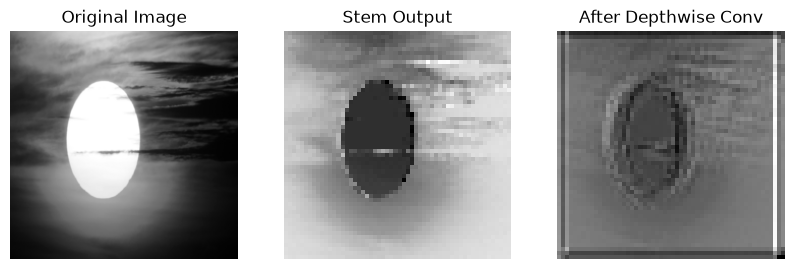

In [8]:
# Let us visualize what we have done so far
plt.figure(figsize=(10,5))
plt.subplot(131)
plt.title('Original Image')
plt.imshow(x.squeeze(), cmap='gray')
plt.axis('off');

plt.subplot(132)
plt.imshow(stem_out.squeeze().detach(), cmap='gray')
plt.title('Stem Output')
plt.axis('off')

plt.subplot(133)
plt.imshow(dw_conv_out.squeeze().detach(), cmap='gray')
plt.title('After Depthwise Conv')
plt.axis('off');

In [9]:
'''
Above, we are able to see after the depthwise conv operation, the pixels have changed. 
At this point, we have only been using 1 channel. So the group operation is behaving the same as the normal convolution

With that in place, we can move on to the next item inspired by ViTs. That is the usage of LayerNorm rather than BatchNorm.

Let us setup a class for this
'''

class ConvNeXtLayerNorm(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.LayerNorm(normalized_shape=channels)

    
    def forward(self, x):
        # x current shape is -> B, C, H, W
        # This needs not to be changed to B, H, W, C
        x = x.permute(0,  2, 3, 1)

        # Apply LayerNorm
        x = self.norm(x)

        # Permute back to the original shape
        x = x.permute(0, 3, 1, 2)

        return x
    

# Test the function
ln = ConvNeXtLayerNorm(channels=in_channels)
ln_out = ln(dw_conv_out)
ln_out.shape

torch.Size([1, 1, 56, 56])

In [10]:
# What does the result look like after LayerNorm?
# Remember, we are looking for a mean of 0 and unit variance / variance 1

print(f'Mean: {ln_out.mean()} Var: {ln_out.var()}')
'''
Ooops that result is problematic. It seems our mean and variance are all 0. Why?

Well for starters, our out_channels above was only 1, similarly our groups = 1 means we were doing the normal convolution.

Also if we were to visualize those 0s, all we would see is a a black image. 

The challenge here is also that our original input has 1 channel. 
This will eb problematic as both the in_channels and out_channels will need to be divisible by the number of groups.
Hence, groups works best beyond the initial input image.

Let us make this a bit more interesting.

We go through the entire process as before.

'''

Mean: 0.0 Var: 0.0


'\nOoops that result is problematic. It seems our mean and variance are all 0. Why?\n\nWell for starters, our out_channels above was only 1, similarly our groups = 1 means we were doing the normal convolution.\n\nAlso if we were to visualize those 0s, all we would see is a a black image. \n\nThe challenge here is also that our original input has 1 channel. \nThis will eb problematic as both the in_channels and out_channels will need to be divisible by the number of groups.\nHence, groups works best beyond the initial input image.\n\nLet us make this a bit more interesting.\n\nWe go through the entire process as before.\n\n'

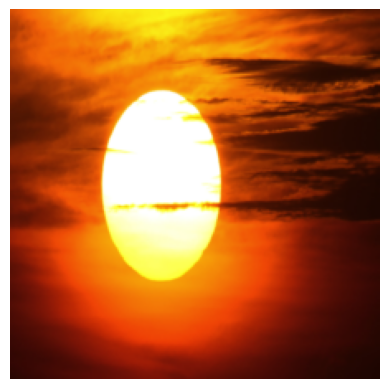

In [11]:
dims = 224
in_channels = 3
out_channels = 4
input_shape = (1, in_channels, dims, dims)

# Let us get an image to work with
# define a url of an image we would like to download
url = "https://static.vecteezy.com/system/resources/thumbnails/012/203/322/original/beautiful-fiery-sunset-in-the-sky-the-sun-sets-over-the-horizon-view-of-the-sun-circle-at-sunset-video.jpg"
response = requests.get(url)
response.raise_for_status()

# Open up the downloaded image
image = Image.open(fp=BytesIO(initial_bytes=response.content))

# With the image in place, prepare to adjust the size for 224,224
transform = transforms.Compose(
    transforms=[
        transforms.Resize(size=(224,224)), # Convert to grayscale
        transforms.ToTensor()   # Make the results a pytorch tensor (C, H, W)
    ]
)

# Apply the transform to the image
x = transform(image).unsqueeze(0)

# Plot the image, so can see what our input looks like
plt.imshow(x.reshape(in_channels, dims, dims).permute(1,2,0))

plt.axis('off');

In [12]:
# Let's now create the new stem
stem = PatchifyStem(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size)
stem_out = stem(x)
print('Stem output shape: ', stem_out.shape)

# Notice we have moved from 3 to 4 channels. 
# Notice once again, the image has been reduced
# Most importantly, while we started off with 3 channels RGB
# These new 4 channels are learned feature 1, learned feature 2, learned feature 3 and learned feature 4
# The concept of RGB has disappeared

# Let's also print the weight tensor since we are here
print('Stem weight: ', stem.proj.weight.shape )

Stem output shape:  torch.Size([1, 4, 56, 56])
Stem weight:  torch.Size([4, 3, 4, 4])


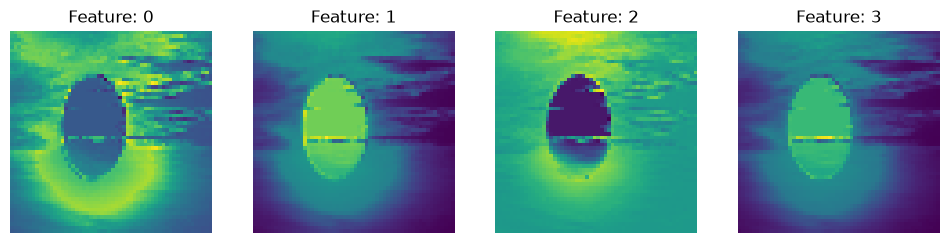

In [13]:
# Let's visualize what has been done
# We expect to see each image is different because each convolution filter has it own initial random values
# Remember, we have not trained a model at this point
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    axes[i].imshow(
        stem_out[0, i, :, :].detach()
    )
    axes[i].set_title(f'Feature: {i}')
    axes[i].axis('off')

plt.show()

In [14]:
# Print the STEM shape
print('Stem weight: ', stem.proj.weight.shape )

# Let us now add the depthsize convolution
# With groups = outchannels = 4, we are taking those 4 incoming features and represent them as 4 individual groups
# Each filter only needs weight for 1 channel
# This means feature 1 -> filter 1; feature 2 -> filter 2;  feature 3 -> filter 3; feature 4 -> filter 4;  
# Each filter only receives one channel
# There is no communication between these channels
dw_conv = DepthWiseConv(in_channels=out_channels, out_channels=out_channels, groups=out_channels)
print('dw_conv weight: ', dw_conv.dwconv.weight.shape)

# Pass through the group convolution
dw_conv_out = dw_conv(stem_out)
print('dwconv out: ', dw_conv_out.shape)

Stem weight:  torch.Size([4, 3, 4, 4])
dw_conv weight:  torch.Size([4, 1, 7, 7])
dwconv out:  torch.Size([1, 4, 56, 56])


In [15]:
# Let us now leverage LayerNorm
# Previously, we had the situation where our 1 channel and 1 group resulted in mean and variance of 0
ln = ConvNeXtLayerNorm(channels=out_channels)
ln_out = ln(dw_conv_out)

print(f'LayerNorm -> mean: {ln_out.mean()} | var: {ln_out.var()}')
# THe output looks more realistic now
# We just changed the scale of the distribution

# Our output shape
ln_out.shape

LayerNorm -> mean: -1.9462740752373975e-08 | var: 0.9992243647575378


torch.Size([1, 4, 56, 56])

In [16]:
# Now that we have the DepthWise convolution
# Let us now get to mixing the information across the feature maps via the 1x1 convolution
# The 1x1 convolution is seen as a channel mixer
# This is where the features talk to each other
# The 1x1 conv is only mixing channels at the same pixel
# Let's implement this channel expansion throuh another class

class ChannelExpansion(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        self.expand = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels * 4,  # idea taken from transformer
            kernel_size=1   # 1x1 convolution
        )


    
    def forward(self, x):
        return self.expand(x)


# Test the class
chnl_exp = ChannelExpansion(in_channels=out_channels)
chnl_exp_out = chnl_exp(ln_out)
chnl_exp_out.shape

# Before each pixel was represented with 4 features
# Now each pixel is represted by 16 features
# Because our kernel size is 1x1, we retain the original input size


torch.Size([1, 16, 56, 56])

In [17]:
# Let us get to the non-linearity now
# GeLU is what is used in the original trransformer, so that is what we will use here too
# Whereas in ReLU all values less than 0 will be cpaped at 0, GELU allows for small non-zero values.
# Smal positive values will be partially passed
# Large positive values are mostly preserved
# From an approximation perspective GELU is: GELU(x) ≈ x * sigmoid(1.702x)

class GELUActivation(nn.Module):
    def __init__(self, ):
        super().__init__()
        self.act = nn.GELU()


    def forward(self, x):
        return self.act(x)


gelu_act = GELUActivation()
gelu_out = gelu_act(chnl_exp_out)
gelu_out.shape

torch.Size([1, 16, 56, 56])

In [18]:
# Let's project back down
class Projection(nn.Module):
    def __init__(self, in_channels ):
        super().__init__()

        self.proj = nn.Conv2d(
            in_channels=out_channels * 4,
            out_channels=out_channels,
            kernel_size=1
        )


    def forward(self, x):
        return self.proj(x)
    

# Test the class
proj = Projection(in_channels=out_channels)
proj_out = proj(gelu_out)
proj_out.shape

torch.Size([1, 4, 56, 56])

In [19]:
# Let's now get the resideual connection by taking our original input and adding it to the projection output
print(stem_out.shape, proj_out.shape)
(stem_out + proj_out).shape

torch.Size([1, 4, 56, 56]) torch.Size([1, 4, 56, 56])


torch.Size([1, 4, 56, 56])

In [20]:
'''
Now that we have all of that, let's package this together into a block

This block follows the transformer style. 


'''

class ConvNeXtBlock(nn.Module):
    def __init__(self, channels=4):
        super().__init__()

        self.dconv = nn.Conv2d(in_channels=channels, out_channels=channels, kernel_size=7, padding=3, groups=channels)
        self.norm = ConvNeXtLayerNorm(channels=channels)
        self.expand = nn.Conv2d(in_channels=channels, out_channels=channels * 4, kernel_size=1)
        self.act = nn.GELU()
        self.proj = nn.Conv2d(in_channels=channels * 4, out_channels=channels, kernel_size=1)

    
    def forward(self, x):
        shortcut = x
        x = self.dconv(x)
        x = self.norm(x)
        x = self.expand(x)
        x = self.act(x)
        x = self.proj(x)

        return x + shortcut # This is where the residual connection comes into play

# Test the class
conv_block = ConvNeXtBlock()

# The input here is the stem output
conv_block_out = conv_block(stem_out)
conv_block_out.shape

torch.Size([1, 4, 56, 56])

In [21]:
# Let's create the downsample
# This downsampling operation replaces what Maxpool does in a traditional Conv network

class DownSample(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        self.norm = ConvNeXtLayerNorm(channels=in_channels)
        self.downsample = nn.Conv2d(
            in_channels=in_channels,
            out_channels=in_channels * 2,
            kernel_size=2,
            stride=2

        )

    
    def forward(self, x):
        return self.downsample(self.norm(x))
    

# Test the class
downsample = DownSample(in_channels=4)
downsample_out = downsample(conv_block_out)
downsample_out.shape

torch.Size([1, 8, 28, 28])

In [22]:
# Put together this as a stage
class Stage(nn.Module):
    def __init__(self, out_channels, num_blocks):
        super().__init__()

        self.blocks = nn.ModuleList(
            [ ConvNeXtBlock(channels=out_channels) for _ in range(num_blocks) ]
        )

    
    def forward(self, x):
        print(f'Stage input: {x.shape}')
        for block in self.blocks:
            x = block(x)
            
            print(f'Stage out shape: {x.shape}')
        return x
    

stage_1 = Stage(out_channels=out_channels, num_blocks=4)
stage_1_out = stage_1(stem_out)
stage_1_out.shape

Stage input: torch.Size([1, 4, 56, 56])
Stage out shape: torch.Size([1, 4, 56, 56])
Stage out shape: torch.Size([1, 4, 56, 56])
Stage out shape: torch.Size([1, 4, 56, 56])
Stage out shape: torch.Size([1, 4, 56, 56])


torch.Size([1, 4, 56, 56])

In [23]:
# Down sample after the stage
down_1 = DownSample(in_channels=4)
dwwn_1_out = down_1(stage_1_out)
dwwn_1_out.shape

torch.Size([1, 8, 28, 28])

In [24]:
# Let's wrap this up by building a MiniConvNeXT

class MiniConvNeXt(nn.Module):
    def __init__(self, out_channels, num_classes=10):
        super().__init__()

        # Build the stem by patchifying
        self.stem = PatchifyStem(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size
        )

        # Stage 1
        self.stage1 = Stage(
            out_channels=out_channels, 
            num_blocks=2
            )

        # Downsample
        self.down1 = DownSample(in_channels=out_channels)

        # Build out stage 2
        self.stage2 = Stage(
            out_channels=out_channels * 2,
            num_blocks=2
        )

        # Downsample 2
        self.down2 = DownSample(in_channels=out_channels * 2)

        # Stage 3
        self.stage3 = Stage(
            out_channels=out_channels * 4,
            num_blocks=2
        )

        # Downsample 3
        self.down3 = DownSample(in_channels=out_channels * 4)


        # Stage 4
        self.stage4 = Stage(
            out_channels=out_channels * 8,
            num_blocks=2
        )

        # Setup a classification head
        self.pool = nn.AdaptiveAvgPool2d(output_size=(1,1))

        # Layer Norm
        self.ln = nn.LayerNorm(normalized_shape=out_channels * 8)

        # Build the classification head
        self.head = nn.Linear(in_features=out_channels * 8, out_features=num_classes)





    
    def forward(self, x):
        print(f'input shape: {x.shape}')

        x = self.stem(x)
        print(f'Stem shape: {x.shape}')

        x = self.stage1(x)
        print(f'Stage 1 shape: {x.shape}', end='\n')

        x = self.down1(x)
        print(f'Downsample 1 shape: {x.shape}', end='\n')

        x = self.stage2(x)
        print(f'Stage 2 shape: {x.shape}', end='\n')

        x = self.down2(x)
        print(f'Downsample 2 shape: {x.shape}', end='\n')

        x = self.stage3(x)
        print(f'Stage 3 shape: {x.shape}', end='\n')

        x = self.down3(x)
        print(f'Downsample 3 shape: {x.shape}', end='\n')

        x = self.stage4(x)
        print(f'Stage 4 shape: {x.shape}', end='\n')

        x = self.pool(x)
        print(f'Pool shape: {x.shape}', end='\n')

        # Flatten x
        # Currently x has shape (batch, channels, height, weight)
        x = torch.flatten(input=x, start_dim=1, end_dim=-1)
        print(f'Flatten output shape: {x.shape}', end='\n')
        
        x = self.ln(x)
        print(f'LayerNorm shape: {x.shape}', end='\n')

        x = self.head(x)
        print(f'Classification shape: {x.shape}', end='\n')

        return x
    

# Test the final class
# Remember the input is -> torch.Size([1, 3, 224, 224])

mini_conv = MiniConvNeXt(out_channels=out_channels)
mini_conv_out = mini_conv(x)
mini_conv_out.shape

input shape: torch.Size([1, 3, 224, 224])
Stem shape: torch.Size([1, 4, 56, 56])
Stage input: torch.Size([1, 4, 56, 56])
Stage out shape: torch.Size([1, 4, 56, 56])
Stage out shape: torch.Size([1, 4, 56, 56])
Stage 1 shape: torch.Size([1, 4, 56, 56])
Downsample 1 shape: torch.Size([1, 8, 28, 28])
Stage input: torch.Size([1, 8, 28, 28])
Stage out shape: torch.Size([1, 8, 28, 28])
Stage out shape: torch.Size([1, 8, 28, 28])
Stage 2 shape: torch.Size([1, 8, 28, 28])
Downsample 2 shape: torch.Size([1, 16, 14, 14])
Stage input: torch.Size([1, 16, 14, 14])
Stage out shape: torch.Size([1, 16, 14, 14])
Stage out shape: torch.Size([1, 16, 14, 14])
Stage 3 shape: torch.Size([1, 16, 14, 14])
Downsample 3 shape: torch.Size([1, 32, 7, 7])
Stage input: torch.Size([1, 32, 7, 7])
Stage out shape: torch.Size([1, 32, 7, 7])
Stage out shape: torch.Size([1, 32, 7, 7])
Stage 4 shape: torch.Size([1, 32, 7, 7])
Pool shape: torch.Size([1, 32, 1, 1])
Flatten output shape: torch.Size([1, 32])
LayerNorm shape: t

torch.Size([1, 10])

In [25]:
x.shape
kernel_size

4